Name - Kuvam Sharma

Student ID - iitp_aiml_2506443

# Data Loading & Exploration

In [ ]:
import pandas as pd
import numpy as np


# Set random seed for reproducibility
np.random.seed(42)


# Generate synthetic credit data
n_samples = 1000


data = {
   'Age': np.random.randint(18, 75, n_samples),
   'Sex': np.random.choice(['male', 'female'], n_samples),
   'Job': np.random.choice([0, 1, 2, 3], n_samples, p=[0.2, 0.4, 0.3, 0.1]),
   'Housing': np.random.choice(['own', 'rent', 'free'], n_samples, p=[0.6, 0.3, 0.1]),
   'Saving accounts': np.random.choice(['little', 'moderate', 'quite rich', 'rich', None],
                                      n_samples, p=[0.4, 0.3, 0.1, 0.1, 0.1]),
   'Checking account': np.random.choice(['little', 'moderate', 'rich', None],
                                       n_samples, p=[0.5, 0.25, 0.15, 0.1]),
   'Credit amount': np.random.randint(250, 20000, n_samples),
   'Duration': np.random.randint(4, 72, n_samples),
   'Purpose': np.random.choice(['car', 'furniture', 'radio/TV', 'education', 'business',
                               'domestic appliances', 'repairs', 'vacation/others'],
                              n_samples, p=[0.3, 0.15, 0.2, 0.1, 0.1, 0.05, 0.05, 0.05])
}


# Create target based on business rules with some randomness
def generate_risk(row):
   risk_score = 0

   # Age factor
   if row['Age'] < 25:
       risk_score += 15
   elif row['Age'] > 60:
       risk_score += 10

   # Credit amount and duration factor
   if row['Credit amount'] > 10000:
       risk_score += 20
   if row['Duration'] > 36:
       risk_score += 15

   # Savings and checking
   if pd.isna(row['Saving accounts']) or row['Saving accounts'] == 'little':
       risk_score += 20
   if pd.isna(row['Checking account']) or row['Checking account'] == 'little':
       risk_score += 15

   # Job stability
   if row['Job'] == 0:
       risk_score += 25

   # Random noise
   risk_score += np.random.randint(-10, 10)

   # Threshold
   return 'bad' if risk_score > 50 else 'good'


df = pd.DataFrame(data)
df['Risk'] = df.apply(generate_risk, axis=1)


# Save to CSV
df.to_csv('german_credit_data.csv', index=False)
print(f"Dataset created: {len(df)} rows")
print(f"Risk distribution:\n{df['Risk'].value_counts()}")


Dataset created: 1000 rows
Risk distribution:
Risk
good    604
bad     396
Name: count, dtype: int64


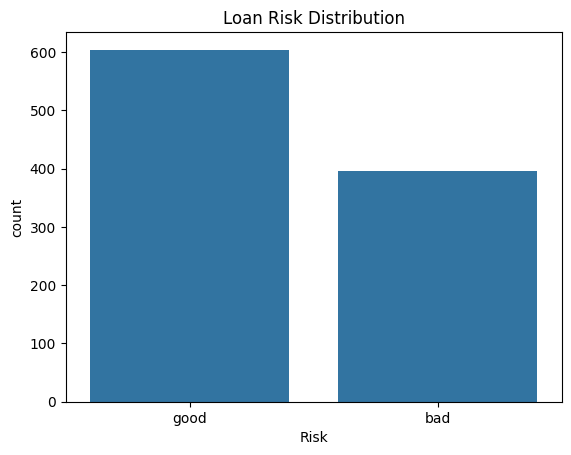

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Risk', data=df)
plt.title("Loan Risk Distribution")
plt.show()

In [ ]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,56,male,1,own,little,moderate,6745,22,car,good
1,69,female,2,free,moderate,moderate,10437,70,car,good
2,46,male,3,own,quite rich,little,9763,8,car,good
3,32,female,1,own,moderate,little,18964,70,radio/TV,bad
4,60,male,2,own,moderate,little,17650,14,domestic appliances,good
...,...,...,...,...,...,...,...,...,...,...
995,37,male,1,own,little,little,11121,44,domestic appliances,bad
996,41,male,3,own,quite rich,little,7860,69,car,good
997,22,male,2,free,little,little,11327,57,furniture,bad
998,51,male,0,rent,moderate,little,16041,43,car,bad


In [ ]:
df.shape

(1000, 10)

In [ ]:
df.dtypes

,0
Age,int64
Sex,object
Job,int64
Housing,object
Saving accounts,object
Checking account,object
Credit amount,int64
Duration,int64
Purpose,object
Risk,object


4 features are numerical and 6 feature (including risk ) are categorical

In [ ]:
df.duplicated().sum()

np.int64(0)

This shows that there are no duplicate rows which is really good as model will not be learning same thing again and again

In [ ]:
numerical_df = df.select_dtypes(include = ["number"])
numerical_df

,Age,Job,Credit amount,Duration
0,56,1,6745,22
1,69,2,10437,70
2,46,3,9763,8
3,32,1,18964,70
4,60,2,17650,14
...,...,...,...,...
995,37,1,11121,44
996,41,3,7860,69
997,22,2,11327,57
998,51,0,16041,43


Above cell shows the description of each numerical columns

In [ ]:
categorical_df = df.select_dtypes(include = ["object"])
categorical_df

,Sex,Housing,Saving accounts,Checking account,Purpose,Risk
0,male,own,little,moderate,car,good
1,female,free,moderate,moderate,car,good
2,male,own,quite rich,little,car,good
3,female,own,moderate,little,radio/TV,bad
4,male,own,moderate,little,domestic appliances,good
...,...,...,...,...,...,...
995,male,own,little,little,domestic appliances,bad
996,male,own,quite rich,little,car,good
997,male,free,little,little,furniture,bad
998,male,rent,moderate,little,car,bad


Above cell shows the description of each categorical columns

In [ ]:
numerical_df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,46.247000,1.306000,9943.912000,36.810000
std,16.288072,0.901763,5626.476201,19.334418
min,18.000000,0.000000,298.000000,4.000000
25%,33.000000,1.000000,5021.250000,21.000000
50%,46.000000,1.000000,9814.000000,36.000000
75%,60.250000,2.000000,14785.500000,53.000000
max,74.000000,3.000000,19893.000000,71.000000


The age values go from young adults to elderly, but most borrowers are around  their 40s, so the dataset is dominated by middle-aged customers.

Job values are mostly 1–2, meaning most people fall in the average employment category rather than extreme cases.

Credit amount has a very wide range and a big spread, which suggests some people take much larger loans than others.

Duration is centered near 36 months, so most loans are medium term, though a few last much longer.

Higher credit amounts and longer repayment durations could be linked to higher risk since they represent bigger financial commitments.

In [ ]:
for col in categorical_df:
  print(f"\nColumn: {col}")
  print(categorical_df[col].value_counts(dropna = False))


Column: Sex
Sex
male      523
female    477
Name: count, dtype: int64

Column: Housing
Housing
own     589
rent    309
free    102
Name: count, dtype: int64

Column: Saving accounts
Saving accounts
little        412
moderate      303
rich          117
None           85
quite rich     83
Name: count, dtype: int64

Column: Checking account
Checking account
little      505
moderate    265
rich        135
None         95
Name: count, dtype: int64

Column: Purpose
Purpose
car                    289
radio/TV               196
furniture              136
business               111
education              109
domestic appliances     67
vacation/others         48
repairs                 44
Name: count, dtype: int64

Column: Risk
Risk
good    604
bad     396
Name: count, dtype: int64


The dataset has almost equal numbers of males and females, so there is no strong gender imbalance.

Most customers own their house, very few live on rent and only a small group live for free.

In savings accounts, the majority have little or moderate savings, and a significant amount did not provide savings information.

Checking accounts show a similar trend, with most customers having low balances and some missing information.

Loans are mainly taken for cars and electronics, while purposes like repairs or vacations are less common.

The target variable shows more good loans than bad ones, but the difference is not extreme.



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   915 non-null    object
 5   Checking account  905 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,85
Checking account,95
Credit amount,0
Duration,0
Purpose,0
Risk,0


This shows that there are 85 and 95 empty entires in saving accounts & checking account respectively

Is this missingess random or predictive??

In [ ]:
df[df.isna().any(axis = 1)] # Printing the rows which have empty entries

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
9,40,male,2,free,None,little,12307,15,radio/TV,bad
11,28,male,1,own,rich,None,19472,5,radio/TV,good
14,53,male,1,own,None,little,8621,51,business,bad
20,19,female,2,own,None,moderate,13793,32,radio/TV,good
24,55,male,1,rent,quite rich,None,8183,45,business,good
...,...,...,...,...,...,...,...,...,...,...
978,55,female,0,own,little,None,6032,34,education,bad
979,50,male,1,own,little,None,17577,29,domestic appliances,good
985,68,male,1,free,None,little,328,69,furniture,bad
986,34,male,0,own,moderate,None,3373,69,car,good


# Exploratory Data Analysis (EDA)

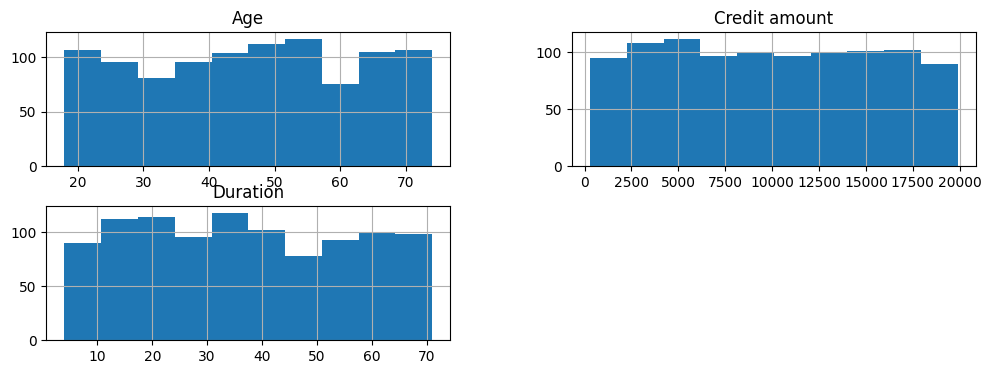

In [ ]:
df[['Age','Credit amount','Duration']].hist(figsize=(12,4))
plt.show()

Age peaks around 50–60 showing that middle-aged borrowers dominate.

Credit amount is right-skewed beacuse most people borrow moderate amounts

Duration peaks around 36 months →showing that most loans are medium-term.


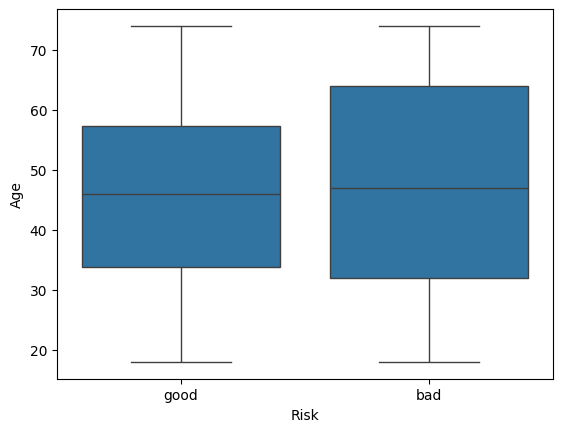

In [ ]:
sns.boxplot(x='Risk', y='Age', data=df)
plt.show()

In [ ]:
df.groupby('Risk')['Age'].mean()

,Age
Risk,
bad,46.893939
good,45.822848


Age doesn’t clearly separate defaulters from non-defaulters. Some age groups differ slightly, but nothing strong on its own.

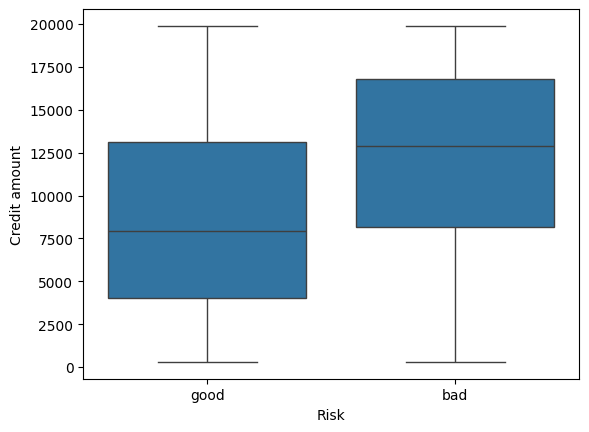

In [ ]:
sns.boxplot(x='Risk', y='Credit amount', data=df)
plt.show()

In [ ]:
df.groupby("Risk")["Credit amount"].mean()

,Credit amount
Risk,
bad,12080.212121
good,8543.291391


People borrowing higher amounts seem to default more often, so larger loans look riskier.

This is a recurring pattern in the world of banking.

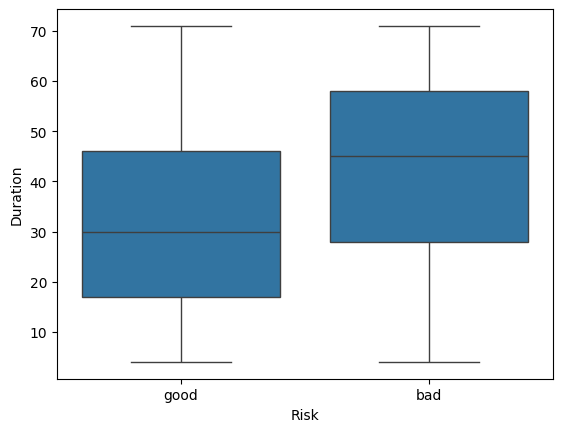

In [ ]:
sns.boxplot(x='Risk', y='Duration', data=df)
plt.show()


In [ ]:
df.groupby("Risk")["Duration"].mean()

,Duration
Risk,
bad,42.896465
good,32.819536


Longer loans show more defaults ( 13% more ), probably because longer the repayment period, easier it is for something to go wrong.

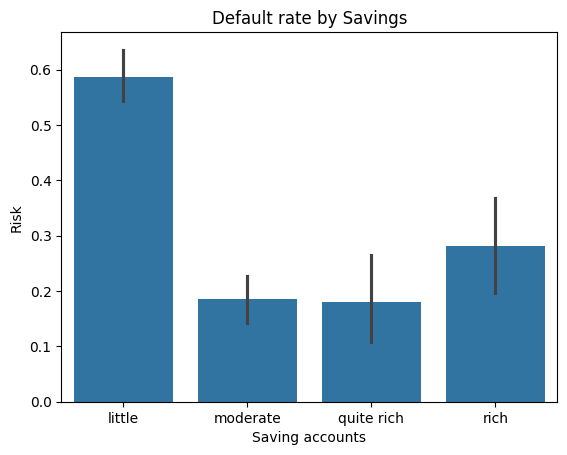

In [ ]:
sns.barplot(x='Saving accounts', y=(df['Risk']=='bad').astype(int), data=df)
plt.title("Default rate by Savings")
plt.show()

Customers with low or unknown savings default noticeably more. Having some financial backup clearly helps.

They might be thinking that even if they default, the seizing of their account won't matter actually matter them.

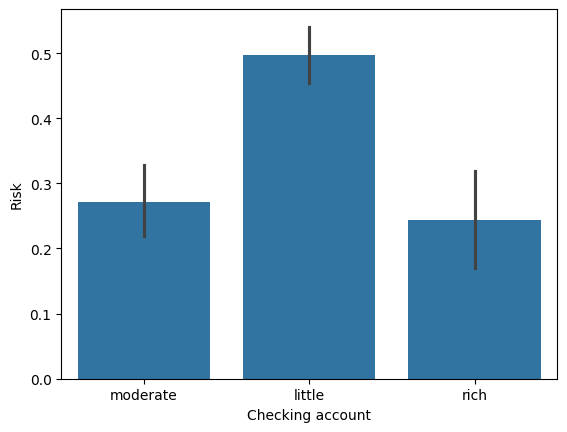

In [ ]:
sns.barplot(x='Checking account', y=(df['Risk']=='bad').astype(int), data=df)
plt.show()

Checking balance matters a little, but the effect isn’t very strong compared to savings.

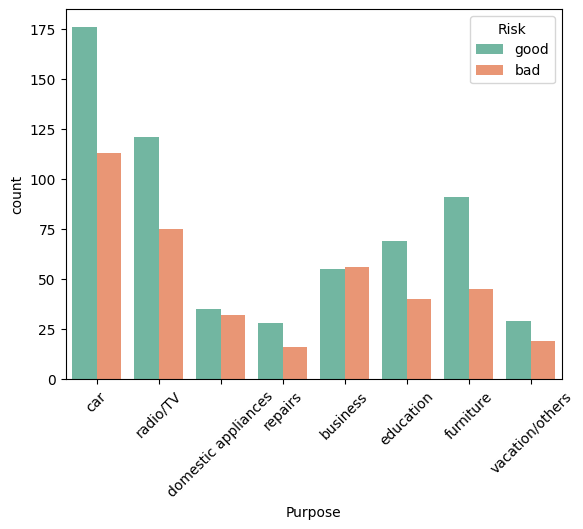

In [ ]:
sns.countplot(x ="Purpose", hue ="Risk", data=df, palette ="Set2")
plt.xticks(rotation=45)
plt.show()

This might seems like people buying loan stating the purpose as to buy a car are defaulting more but this finding is very proportionate with the other classes.

Hence this does not actually provide us with a solid insight about which stated purpose leads to more defaulter.

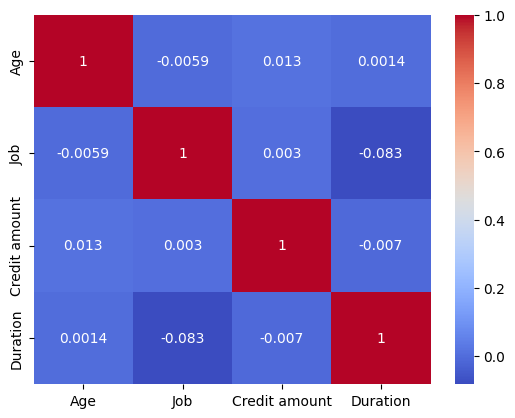

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

The numeric features aren’t strongly related to each other, so each one is giving different information.

The most strong correlation is between job & duration but that is also very insignificant.

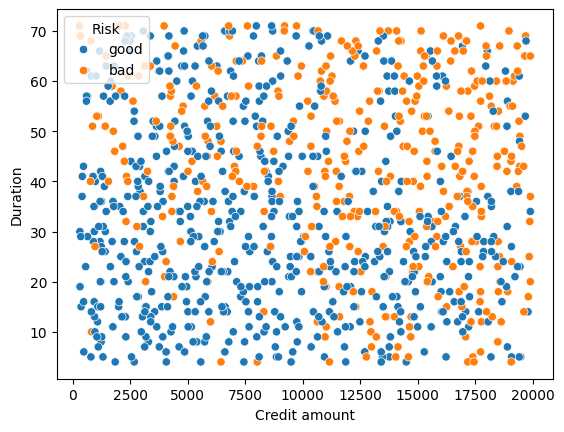

In [ ]:
sns.scatterplot(x='Credit amount', y='Duration', hue='Risk', data=df)
plt.show()


The best appears on the lower left side of plot where both the loan is small and the repayment time is also short.

The worst cases mostly appear where both the loan is big and the repayment time is long.

# EDA Conclusion


Customers who don't disclose savings default at 58.8% vs 37.8% — the silence itself is a red flag, so we kept it as a feature instead of imputing it.

Bigger loans + longer durations = more defaults. Monthly_Burden was created to capture that combined pressure in one number.

Job level 0 and low savings consistently appear in the bad risk group, while loan purpose alone turned out to be a weak predictor once proportions were accounted for.

Preprocessing followed the data — ordinal encoding for account columns (because rich > little is a real order), missing values kept as a category, and StandardScaler applied because Age and Credit amount live on completely different scales.

# Feature Engineering Section

In [ ]:
df['Saving_missing'] = df['Saving accounts'].isna()
df['Checking_missing'] = df['Checking account'].isna()

print(pd.crosstab(df['Saving_missing'], df['Risk'], normalize='index'))
print(pd.crosstab(df['Checking_missing'], df['Risk'], normalize='index'))

Risk                 bad      good
Saving_missing                    
False           0.378142  0.621858
True            0.588235  0.411765
Risk                   bad      good
Checking_missing                    
False             0.393370  0.606630
True              0.421053  0.578947


There are total 174 empty rows but,

85 + 95 = 180 not 174

Therefore, 6 rows have empty entires in both columns

| Missing? | Bad rate  |
| -------- | --------- |
| False    | **37.8%** |
| True     | **58.8%** |

So people without declared savings default way more, thats insighful

| Missing? | Bad rate  |
| -------- | --------- |
| False    | **39.3%** |
| True     | **42.1%** |

Just a tiny increase, not very meaningful

This shows that customers who don’t report their savings are much more likely to default, so the missing values in the Saving accounts column carry meaningful information.

In contrast, missing values in the Checking account column have only a small effect on default risk and are not very informative.

So I'm gonna keep the missing as a categorical data in Saving accounts
& Checking account as they contain some insightful information

In [ ]:
df["Monthly_Burden"] = df["Credit amount"]/ df["Duration"]
df["Monthly_Burden"]
# This is the Credit_to_Duration_Ratio mentioned in the guideline prospectus

,Monthly_Burden
0,306.590909
1,149.100000
2,1220.375000
3,270.914286
4,1260.714286
...,...
995,252.750000
996,113.913043
997,198.719298
998,373.046512


In [ ]:
df.groupby("Risk")["Monthly_Burden"].mean()

,Monthly_Burden
Risk,
bad,455.115374
good,435.982360


The average monthly repayment amount is similar for both good and bad loans, indicating that default risk is not determined by EMI alone.

Instead, default likely depends on a combination of financial factors rather than a single repayment metric.

Smaller less significant factors combine to make a noticeable outcome not just one parameter influence risk.


In [ ]:
df['Age_Group'] = pd.cut(df['Age'],
                         bins=[18, 25, 35, 50, 100],
                         labels=[0,1,2,3],
                         include_lowest=True).astype(int)

print(df[['Age', 'Age_Group']].head())

   Age  Age_Group
0   56          3
1   69          3
2   46          2
3   32          1
4   60          3


Creating 2 new features -> Saving Accounts & Checking Accounts

Each account level is mapped to a number (little = 1 → rich = 4) and summed into a single score from 0 to 7.

Missing accounts fill as 0 — not arbitrary, but intentional.

EDA showed undisclosed accounts correlate with higher default
risk, so 0 correctly places them at the bottom of the stability scale.

In [ ]:
saving_map = {"little":1, "moderate":2, "quite rich":3, "rich":4}
checking_map = {"little":1, "moderate":2, "rich":3}
df["Account_stability"] = (
    df["Saving accounts"].map(saving_map).fillna(0)+
    df["Checking account"].map(checking_map).fillna(0)
)

A High_Risk_Purpose flag was considered but discarded — EDA showed
- that default rates across loan purposes were proportionate to their frequency,
- Meaning purpose carries no meaningful predictive signal on its own.

# Data Preprocessing

In [ ]:
df["Risk"].unique()

array(['good', 'bad'], dtype=object)

Binary Mapping the target column (risk)

In [ ]:
df['Risk'] = df['Risk'].str.strip().str.lower() # This line is added for error minimization
df['Risk'] = df['Risk'].map({'good':0, 'bad':1})

In [ ]:
df["Risk"].value_counts(dropna = False)

,count
Risk,
0,604
1,396


Importing The Encoder and Transformers for a smooth and clean encoding and pipelining

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

Now inititializing columns with respect to their type of mapping or encoding

In [ ]:
ordinal_cols = ['Saving accounts','Checking account']
onehot_cols  = ['Sex','Housing','Purpose']
numeric_cols = ['Job', 'Credit amount', 'Duration','Monthly_Burden',
                'Age_Group','Account_stability',
                'Saving_missing', 'Checking_missing']

saving_order   = ['little','moderate','quite rich','rich']
checking_order = ['little','moderate','rich']

Raw Age is dropped in favour of Age_Group since EDA showed a non-linear .

U-shaped risk pattern (youth and elderly both higher risk), which binning captures better.

Binary mapping Saving_missing & Checking_missing columns

In [ ]:
df['Saving_missing'] = df['Saving_missing'].astype(int)
df['Checking_missing'] = df['Checking_missing'].astype(int)

Applying Ordinal & OneHot Encoding on categorical columns using Column Transformer

Applying Standard Scaler on numerical columns using Column Transformer

In [ ]:
ord_encoder = OrdinalEncoder(
    categories=[saving_order, checking_order],
    handle_unknown='use_encoded_value',
   unknown_value=-1)
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', ord_encoder, ordinal_cols),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), onehot_cols),
        ('num', StandardScaler(), numeric_cols)])

Applying Train (80%)-Test (20%) Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Risk', axis=1)
y = df['Risk']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_train = preprocessor.fit_transform(X_train)
X_test  = preprocessor.transform(X_test)


But X_train and X_test is a NumPy array now so converting it to pandas Dataframe in order to continue with a more scalable product

In [ ]:
final_columns = preprocessor.get_feature_names_out()
X_train = pd.DataFrame(X_train, columns=final_columns, index=y_train.index)
X_test  = pd.DataFrame(X_test,  columns=final_columns, index=y_test.index)


In [ ]:
X_train

,ord__Saving accounts,ord__Checking account,ohe__Sex_male,ohe__Housing_own,ohe__Housing_rent,ohe__Purpose_car,ohe__Purpose_domestic appliances,ohe__Purpose_education,ohe__Purpose_furniture,ohe__Purpose_radio/TV,ohe__Purpose_repairs,ohe__Purpose_vacation/others,num__Job,num__Credit amount,num__Duration,num__Monthly_Burden,num__Age_Group,num__Account_stability,num__Saving_missing,num__Checking_missing
83,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.785170,1.322484,-1.646042,5.145169,0.944258,-0.130352,-0.299864,-0.321634
467,1.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.785170,1.545144,-1.076835,1.224232,0.944258,1.308014,-0.299864,-0.321634
274,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.894950,1.234828,-0.559375,0.348786,-1.892061,-0.130352,-0.299864,-0.321634
611,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-1.434391,1.256830,-0.921597,0.765862,0.944258,-0.130352,-0.299864,-0.321634
914,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.894950,-0.465307,0.423800,-0.480355,0.944258,-0.849535,-0.299864,-0.321634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
953,-1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.324611,1.712711,-1.180327,1.621992,-0.946621,-1.568718,3.334848,-0.321634
410,3.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.324611,-0.615976,0.630784,-0.532233,0.944258,2.027197,-0.299864,-0.321634
151,0.0,-1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.434391,-0.448409,1.406975,-0.558754,0.944258,-1.568718,-0.299864,3.109126
499,3.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,-0.324611,0.412835,-1.128581,0.628879,-1.892061,1.308014,-0.299864,-0.321634


In [ ]:
X_test

,ord__Saving accounts,ord__Checking account,ohe__Sex_male,ohe__Housing_own,ohe__Housing_rent,ohe__Purpose_car,ohe__Purpose_domestic appliances,ohe__Purpose_education,ohe__Purpose_furniture,ohe__Purpose_radio/TV,ohe__Purpose_repairs,ohe__Purpose_vacation/others,num__Job,num__Credit amount,num__Duration,num__Monthly_Burden,num__Age_Group,num__Account_stability,num__Saving_missing,num__Checking_missing
246,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.785170,-1.436737,1.148245,-0.703658,-1.892061,-0.849535,-0.299864,-0.321634
865,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-1.434391,1.478434,0.889514,-0.179055,0.944258,0.588831,-0.299864,-0.321634
40,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.785170,1.155621,1.613959,-0.342950,0.944258,-0.130352,-0.299864,-0.321634
806,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.785170,-1.141383,-1.283819,-0.273299,0.944258,-0.130352,-0.299864,-0.321634
64,3.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.785170,0.278359,0.268562,-0.290316,0.944258,1.308014,-0.299864,-0.321634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.324611,1.213179,1.665705,-0.340858,0.944258,-0.130352,-0.299864,-0.321634
755,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-0.324611,-1.598847,-1.646042,-0.483068,0.944258,-0.849535,-0.299864,-0.321634
16,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.785170,1.526310,-0.611121,0.505171,-0.001182,-0.849535,-0.299864,-0.321634
977,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.324611,-0.694831,-0.766359,-0.295817,0.944258,-1.568718,3.334848,-0.321634


# Saving the raw split

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os
os.makedirs("/content/drive/MyDrive/ml", exist_ok=True)

In [ ]:
import joblib
joblib.dump(X_train, "/content/drive/MyDrive/T2_Project_Kuvam_Sharma_iitp_aiml_2506443/Data/X_train.pkl")
joblib.dump(X_test, "/content/drive/MyDrive/T2_Project_Kuvam_Sharma_iitp_aiml_2506443/Data/X_test.pkl")
joblib.dump(y_train, "/content/drive/MyDrive/T2_Project_Kuvam_Sharma_iitp_aiml_2506443/Data/y_train.pkl")
joblib.dump(y_test, "/content/drive/MyDrive/T2_Project_Kuvam_Sharma_iitp_aiml_2506443/Data/y_test.pkl")

['/content/drive/MyDrive/T2_Project_Kuvam_Sharma/Data/y_test.pkl']